In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [27]:
original_train_df = pd.read_csv("data/train.csv")

ADD VIX PROXY AS NEW VOLATILITY METRIC

Mean Squared Error: 6.9586
R-squared: 0.8395


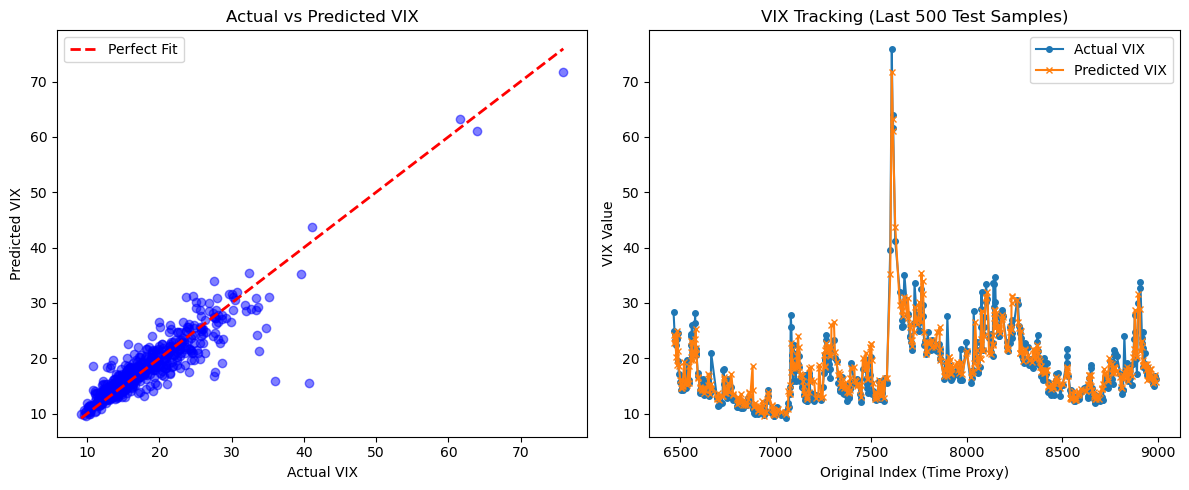

In [28]:
vix_df = pd.read_csv("VIX_History.csv")["CLOSE"]
train_cols = original_train_df.columns
vol_cols = [c for c in train_cols if "V" in c]
vol_df = original_train_df[vol_cols].copy()
vol_df["target"] = vix_df
vol_df = vol_df.dropna()

X = vol_df.drop('target', axis=1)
y = vol_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
line_coords = np.array([y_test.min(), y_test.max()])
plt.plot(line_coords, line_coords, 'r--', lw=2, label="Perfect Fit")
plt.xlabel('Actual VIX')
plt.ylabel('Predicted VIX')
plt.title('Actual vs Predicted VIX')
plt.legend()

plt.subplot(1, 2, 2)
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).sort_index()

last_500_idx = results_df.index[-500:]
plt.plot(last_500_idx, results_df['Actual'].loc[last_500_idx], label='Actual VIX', marker='o', markersize=4)
plt.plot(last_500_idx, results_df['Predicted'].loc[last_500_idx], label='Predicted VIX', marker='x', markersize=4)
plt.xlabel('Original Index (Time Proxy)')
plt.ylabel('VIX Value')
plt.title('VIX Tracking (Last 500 Test Samples)')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
new_df = original_train_df.copy()
new_df = new_df.drop(vol_cols, axis=1)
new_df.loc[X.index, "VIX"] = model.predict(X)
new_df["VIX"] = new_df["VIX"].rank(pct=True)  #VIX as historical percentile

In [30]:
new_df.columns

Index(['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1',
       'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
       'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3',
       'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13',
       'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7',
       'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5',
       'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4',
       'S5', 'S6', 'S7', 'S8', 'S9', 'forward_returns', 'risk_free_rate',
       'market_forward_excess_returns', 'VIX'],
      dtype='object')

In [31]:
df = new_df.dropna(subset=['forward_returns']).copy()
not_features = ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
# Fill NAs in features with 0 for this quick test
features = [col for col in df.columns if col not in not_features]
X = df[features].fillna(0)
y = df['forward_returns']

print(f"Training Random Forest on {len(features)} features")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

#display(importances)

#Drop features following the 1/N heuristic
n_features = len(features)
threshold = 1.0 / n_features
print(f"\n1/N Threshold: {threshold:.4f}")

# Select features that meet the threshold
important_features = importances[importances['Importance'] >= threshold]['Feature'].tolist()
dropped_features = importances[importances['Importance'] < threshold]['Feature'].tolist()

print(f"Keeping {len(important_features)} features.")
print(f"Dropping {len(dropped_features)} features.")

# Update the DataFrame by dropping the unimportant features
new_df = new_df.drop(columns=dropped_features)
print(f"New DataFrame shape after dropping features: {new_df.shape}")


Training Random Forest on 82 features

1/N Threshold: 0.0122
Keeping 36 features.
Dropping 46 features.
New DataFrame shape after dropping features: (8990, 40)


In [32]:
print(new_df.columns)

Index(['date_id', 'E12', 'E17', 'E19', 'E2', 'E6', 'E8', 'I2', 'M10', 'M11',
       'M12', 'M15', 'M2', 'M3', 'M4', 'M7', 'M8', 'P1', 'P10', 'P11', 'P12',
       'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'S12', 'S2', 'S5',
       'S6', 'S7', 'S8', 'S9', 'forward_returns', 'risk_free_rate',
       'market_forward_excess_returns', 'VIX'],
      dtype='object')


<Axes: >

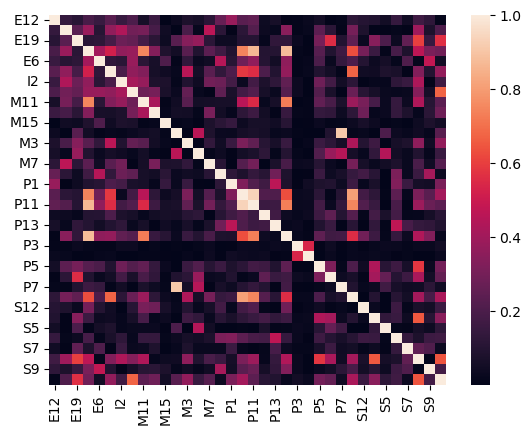

In [33]:
import seaborn as sns
sns.heatmap(new_df.drop(not_features, axis=1).corr().abs())

In [34]:

corr_matrix = new_df.drop(not_features, axis=1).corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Features mapped for removal due to >{threshold} correlation: {len(to_drop)}")
print(to_drop)

# Drop them from the dataframe
new_df = new_df.drop(columns=to_drop)


Features mapped for removal due to >0.9 correlation: 2
['P11', 'P7']
